In [ ]:
from pathlib import Path
import numpy as np
import soundfile as sf
import library as lib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
from sklearn.neighbors import NearestNeighbors

In [ ]:
# --- paths and config -------------------------------------------------
AUDIO_FILE = (Path(__file__).parent / ".." / "data" / "nestingbox1"
              / "20240927_204919" / "combined_audio.w64").resolve(strict=True)

BASE_OUT = Path(__file__).parent / "cluster_wavs"
KM_OUT   = BASE_OUT / "kmeans"
SP_OUT   = BASE_OUT / "spectral"
DB_OUT  = BASE_OUT / "dbscan"
HW_OUT  = BASE_OUT / "hier_ward"
TS_OUT  = BASE_OUT / "hier_two_step"
for d in (KM_OUT, SP_OUT, DB_OUT, HW_OUT, TS_OUT):
    d.mkdir(parents=True, exist_ok=True)

cfg = lib.Config()          # default parameters
N_NEIGHBORS = 10
print('Config loaded')

Config loaded


In [ ]:
def plot_scatter(title, labels):
    uniq = np.unique(labels)
    lab2idx = {lab: i for i, lab in enumerate(uniq)}
    colors = np.vectorize(lab2idx.get)(labels)
    cmap   = plt.cm.get_cmap('tab10', len(uniq))
    plt.figure();  plt.title(title)
    plt.scatter(X_red[:,0], X_red[:,1], c=colors, cmap=cmap, s=8)
    handles = [Line2D([],[],marker='o',linestyle='',
                      color=cmap(i), markersize=6,
                      label=("noise" if lab==-1 else f"cluster_{lab:03d}.wav"))
               for lab,i in lab2idx.items()]
    plt.legend(handles=handles, frameon=False, title="Concatenated snippet")
    plt.xlabel("PC-1"); plt.ylabel("PC-2"); plt.tight_layout(); plt.show()

print("Helper utilities ready to run the pipeline.")

Helper utilities ready to run the pipeline.


In [ ]:
# --- stream, filter, detect ------------------------------------------
all_feats   = []
all_segs    = []

for chunk, offset in lib.iter_audio_chunks(AUDIO_FILE, cfg):
    segs = lib.detect_segments(chunk, cfg.sample_rate, cfg, offset)  # band-pass inside
    for s, e in tqdm(segs,
                     desc=f"Features @ {offset/cfg.sample_rate/3600:.1f}h",
                     leave=False,
                     unit="seg"):
        local = chunk[s - offset:e - offset]
        spec_vec  = lib.segment_spectro_db(local, cfg.sample_rate, cfg)
        broad_vec = lib.extract_broad_features_segment(local, cfg.sample_rate, cfg)
        feat_vec  = np.hstack([spec_vec, broad_vec])       # concatenate
        all_feats.append(feat_vec)

    all_segs.extend(segs)

assert all_feats, "No segments detected; adjust thresholds."

X = np.stack(all_feats)
scaler = StandardScaler()
X = scaler.fit_transform(X)
print(f"segments={len(X)}, feature-dim={X.shape[1]}")

Streaming audio: 100%|██████████| 13/13 [04:43<00:00, 21.81s/chunk]

segments=2941, feature-dim=517


In [ ]:
# --- dimensionality reduction ----------------------------------------
X_red, pca = lib.reduce_dim(X, cfg)
print(f"PCA  →  {X_red.shape[1]} dimensions")

PCA  →  81 dimensions


In [ ]:
#optional for choosing k number of clusters

K_CLUSTERS = 5
print(f"{K_CLUSTERS} number of clusters is set")

5 number of clusters is set


cluster sizes (k-means):   [1008  261 1205  265  202]


Snippets → kmeans: 100%|██████████| 2941/2941 [00:02<00:00, 1150.23wav/s]
<ipython-input-3-dd1d59d4829b>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', len(uniq))


Done.  WAVs saved under C:\Users\pigby\OneDrive - Johns Hopkins\Vocalization\new_scripts\cluster_wavs


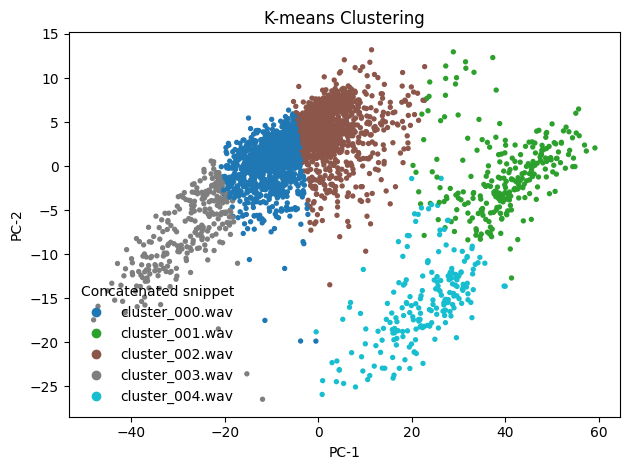

In [ ]:
# --- kmeans clustering -------------------------------------------------------
lab_km = lib.cluster_kmeans(X_red, K_CLUSTERS, cfg)
print("cluster sizes (k-means):  ", np.bincount(lab_km))
lib.save_cluster_snippets(AUDIO_FILE, cfg.sample_rate, all_segs, lab_km, KM_OUT, concat=True)

print("Done.  WAVs saved under", BASE_OUT.resolve())

#plotting ---------- PCA scatter for K-means ----------
plot_scatter("K-means Clustering", lab_km)

cluster sizes (spectral): [1808  269  190   22  652]


Snippets → spectral: 100%|██████████| 2941/2941 [00:01<00:00, 2457.37wav/s]
<ipython-input-3-dd1d59d4829b>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', len(uniq))


Done.  WAVs saved under C:\Users\pigby\OneDrive - Johns Hopkins\Vocalization\new_scripts\cluster_wavs


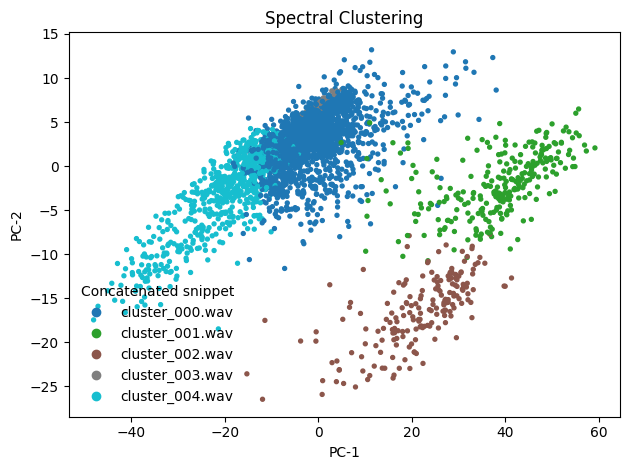

In [ ]:
# --- spectral clustering -------------------------------------------------------
lab_sp = lib.cluster_spectral(X_red, K_CLUSTERS, N_NEIGHBORS, cfg)
print("cluster sizes (spectral):", np.bincount(lab_sp))
lib.save_cluster_snippets(AUDIO_FILE, cfg.sample_rate, all_segs, lab_sp, SP_OUT, concat=True)

print("Done.  WAVs saved under", BASE_OUT.resolve())

#plotting
plot_scatter("Spectral Clustering", lab_sp)

[DBSCAN] eps*=1.00 ⇒ 0 clusters (+ noise)
cluster sizes (DBSCAN): []


Snippets → dbscan: 100%|██████████| 2941/2941 [00:01<00:00, 2426.34wav/s]
<ipython-input-3-dd1d59d4829b>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', len(uniq))


Done.  WAVs saved under C:\Users\pigby\OneDrive - Johns Hopkins\Vocalization\new_scripts\cluster_wavs


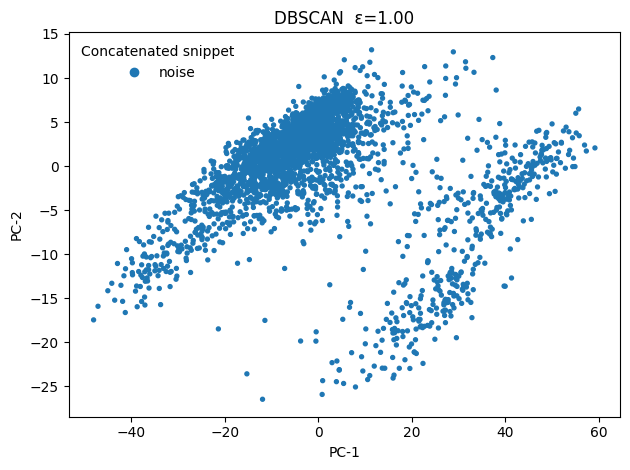

In [ ]:
# --- DBSCAN clustering -------------------------------------------------------
best_eps, lab_db = lib.tune_dbscan(X_red, cfg)
print("cluster sizes (DBSCAN):", np.bincount(lab_db[lab_db>=0]))
lib.save_cluster_snippets(AUDIO_FILE, cfg.sample_rate, all_segs, lab_db,
                          DB_OUT, concat=True)
print("Done.  WAVs saved under", BASE_OUT.resolve())
plot_scatter(f"DBSCAN  ε={best_eps:.2f}", lab_db)

[Ward] dist*=350 → 4 clusters, cost=45.69


Snippets → hier_ward: 100%|██████████| 2941/2941 [00:01<00:00, 2445.72wav/s]
<ipython-input-3-dd1d59d4829b>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', len(uniq))


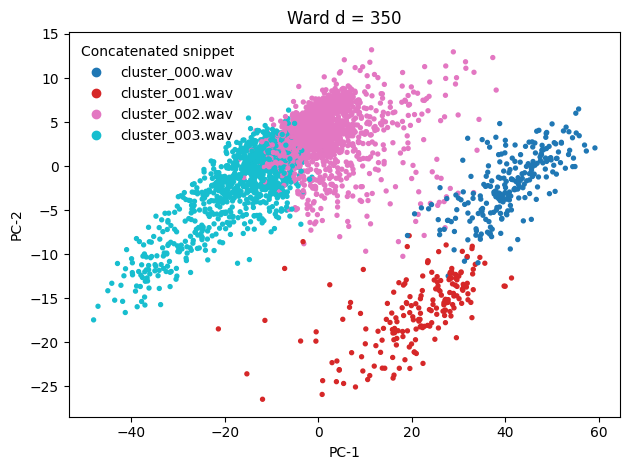

Done.  WAVs saved under C:\Users\pigby\OneDrive - Johns Hopkins\Vocalization\new_scripts\cluster_wavs


In [ ]:
best_d, lab_hw = lib.tune_ward_distance(X_red, cfg)
lib.save_cluster_snippets(AUDIO_FILE, cfg.sample_rate, all_segs, lab_hw,
                          HW_OUT, concat=True)
plot_scatter(f"Ward d = {best_d}", lab_hw)
print("Done.  WAVs saved under", BASE_OUT.resolve())

[2-step Ward] cost=6.16 → 1 clusters
cluster sizes (2-step Ward): [2941]


Snippets → hier_two_step: 100%|██████████| 2941/2941 [00:01<00:00, 2498.85wav/s]
<ipython-input-3-dd1d59d4829b>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', len(uniq))


Done.  WAVs saved under C:\Users\pigby\OneDrive - Johns Hopkins\Vocalization\new_scripts\cluster_wavs


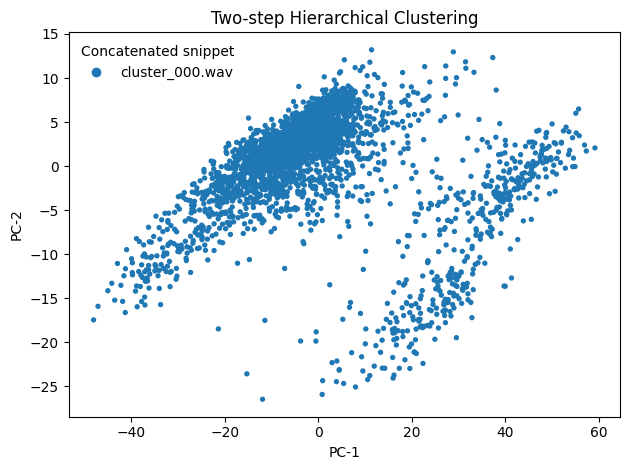

In [ ]:
lab_ts = lib.tune_two_step(X_red, cfg)
print("cluster sizes (2-step Ward):", np.bincount(lab_ts))
lib.save_cluster_snippets(AUDIO_FILE, cfg.sample_rate, all_segs, lab_ts,
                          TS_OUT, concat=True)
print("Done.  WAVs saved under", BASE_OUT.resolve())
plot_scatter("Two-step Hierarchical Clustering", lab_ts)